

It is not extremely clear what is the **best** type of model, but the previous analyses indicate that our base model today should be the following:

* Use Box-Cox
* Use a HL, but only to reduce dimensionality flowing towards the target
* A tanh HL seems slightly better than a sigmoid HL
* Month dummies do not do too much; maybe try using Big4 vars again (?)
* Number of epochs must scale up w/ number of inputs and layers; however, too many epochs seems to reduce recall (while increasing precision)


### SkipGram-Inspired DimRedux Layer
Interestingly, in the last study, I found that the tanh hidden layer (HL) seemed to perform slightly better than the sigmoid HL.  If you think about tanh acting on postive and negative values, it serves to squash them, but symmetrically about zero and maintains their sign; in contrast, sigmoid basically zeros out anything negative.  Though our data starts out positive semi-definite, we rescale/relocate the data to take on values in [-1, 1].  It occurred to be that only slight distortion was going on in the tanh HL, and that maybe no activation function would work better.

Serendipitously, in the Udacity course I'm taking, we covered the Skip-Gram Word2Vec model for predicting sequences of text, etc.  Here the dimensionality reduction layer is called the "embedding layer," and it serves to weed out the redundancy in a spoken language.  Importantly, no activation function is used: the act of reducing the size of the input layer is what's important.  

With this in mind, my first experiment today is to test whether no activation function on the HL works better than the tanh activation.


M0: 8-feature input layer (exl_no_vod), 7-node no-activation HL, 1-node output layer; 8 epochs, LR=0.05

| RO-AUC    |  74.6  | 
| Accuracy  |  93.0  | 
| Precision |  62.1  | 
| Recall    |  4.0  | 
| PR-AUC    |  24.4  | 
| F1 Score  |  7.5  | 
| R2 Score  |  8.8  | 
| MnAbsErr  |  11.7  | 
| MnSqErr   |  6.0  | 
| MedAbsErr |  4.2  | 

M1: 8-feature input layer (exl_no_vod), 7-node tanh HL, 1-node output layer; 8 epochs, LR=0.05
| RO-AUC    |  75.5  | 
| Accuracy  |  93.2  | 
| Precision |  62.5  | 
| Recall    |  10.1  | 
| PR-AUC    |  27.1  | 
| F1 Score  |  17.3  | 
| R2 Score  |  10.6  | 
| MnAbsErr  |  11.7  | 
| MnSqErr   |  5.9  | 
| MedAbsErr |  4.8  | 

M2a: 8-feature input layer (exl_no_vod), 7-node sigmoid HL, 1-node output layer; 8 epochs, LR=0.05
| RO-AUC    |  75.6  | 
| Accuracy  |  93.2  | 
| Precision |  60.7  | 
| Recall    |  10.4  | 
| PR-AUC    |  27.0  | 
| F1 Score  |  17.8  | 
| R2 Score  |  10.6  | 
| MnAbsErr  |  11.8  | 
| MnSqErr   |  5.9  | 
| MedAbsErr |  4.9  | 

M2b: M2a but w/ batch=2500, epochs=8
| RO-AUC    |  75.3  | 
| Accuracy  |  93.1  | 
| Precision |  60.8  | 
| Recall    |  6.3  | 
| PR-AUC    |  25.9  | 
| F1 Score  |  11.4  | 
| R2 Score  |  10.0  | 
| MnAbsErr  |  11.7  | 
| MnSqErr   |  5.9  | 
| MedAbsErr |  4.7  | 

M2c: M2 but w/ batch=2500, epochs=16
| RO-AUC    |  75.6  | 
| Accuracy  |  93.1  | 
| Precision |  62.2  | 
| Recall    |  6.2  | 
| PR-AUC    |  26.0  | 
| F1 Score  |  11.3  | 
| R2 Score  |  10.1  | 
| MnAbsErr  |  11.7  | 
| MnSqErr   |  5.9  | 
| MedAbsErr |  4.7  | 

* Still not perfectly clear whether tanh HL or sigmoid HL is better, but both are better than no activation fcn


...nooooooo, GPU still not making things fast....?????
M2d: M2 but w/ batch=10k and epochs=62;  actually runs pretty fast, despite slight losses in model metrics (especially recall)

| RO-AUC    |  75.5  | 
| Accuracy  |  93.1  | 
| Precision |  62.2  | 
| Recall    |  6.3  | 
| PR-AUC    |  26.0  | 
| F1 Score  |  11.4  | 
| R2 Score  |  10.1  | 
| MnAbsErr  |  11.7  | 
| MnSqErr   |  5.9  | 
| MedAbsErr |  4.7  | 

# 2017-04-24/25

## One Last Look at NXT Var Modifications
Here I will (i) run the Box-Cox version of EXL6+[pos1,pos2,pos3,v1,v2,a1], (ii) the log version of that, and (iii) start adding layers to the best one of those.  Box-Cox does way better on precision.

### Go with Box-Cox
Here we confirm that, in terms of precision and recall, the Box-Cox transformation is the way to go. The log transformation seems to support a slightly better AUC, but performs worse by almost every other metric.

However, overall, it's not clear that the extra NXT variables help us.

* M0: Box(EXL7)
* M1: Box(EXL6 + [pos1,pos2,pos3,v1,v2,a1])
* M2: Log(EXL6 + [pos1,pos2,pos3,v1,v2,a1])

|           | M0    | M1    | M2    |
|-----------|-------|-------|-------|
| RO-AUC    |  75.0 | 75.0  |  75.2 | 
| Accuracy  |  93.1 | 93.1  |  93.0 | 
| Precision |  68.1 | 68.4  |  56.2 | 
| Recall    |  4.9  |  4.8  |  3.5  |  
| PR-AUC    |  25.6 | 25.7  |  24.7 | 
| F1 Score  |  9.2  |  8.9  |  6.6  |  
| R2 Score  |  9.5  |  9.5  |  9.2  |  
| MnAbsErr  | 11.6  | 11.5  |  11.7 | 
| MnSqErr   |  6.0  |  6.0  |  6.0  |  
| MedAbsErr |  4.1  |  4.1  |  4.3  | 



### Add a hidden layer:  Precision vs Recall
It is clear that adding a hidden layer can help.  A HL adds nearly a 1% bump in RO-AUC to the Box(EXL7) model.  
It also increases recall (TP/EP, where EP=FN+TP) from 4.9% to 7.5% (adds 2.6%), which means we are able to accurately identify more cases of churn.
However, precision (TP/MP, where MP=TP+FP) decreases from ~68% to ~64% in the Box(EXL)+HL model, which means we would end up with 
additional false positives.  This is where our goals really matter:  given 1M people and a 10% churn rate, the Box(EXL7) model would reveal 5k of 100k churners; the HL increases this to 7.5k.  However, the precision tells us that 7.5k is ~64% of all model positives, which means there exist 4.2k false positives, whereas the Box(EXL7) model only has ~2.4k false positives.  This becomes a cost-benefit analysis: we correctly discovered 2.5k more churners, but have incorrectly identified an additional 1.8k non-churners as churners.  If we were offering a free month, we might ultimately retain, say, 250 churners for an additional month, but end up giving, say, 750 people a free month who would have otherwise paid, resulting in a net $5k loss.  

Again, for the Box(EXL6+otherVars]) model, we see an overall improvement in RO-AUC
and recall when adding a hidden layer, and a slight decrease in precision. 

#### Dimensionality Reduction Layer
This analysis likely points to the utility of the PR-AUC for churn, which measures the concurrent "goodness" of both
precision and recall.  The F1 score does this as well.  Both are maximized with a hidden layer that reduces the dimensionality.  This is likely an important observation going forward:  as we add more and more features, a dimensionality reduction layer will likely become very important. 

* M0a: Box(EXL7)
* M0b: Box(EXL7) with 7-node Sigmoid HL 
* M1a: Box(EXL6+[p1,p2,p3,v1,v2,a1])
* M1b: Box(EXL6+[p1,p2,p3,v1,v2,a1]) with 7-node Sigmoid HL
* M1c: Box(EXL6+[p1,p2,p3,v1,v2,a1]) with 12-node Sigmoid HL


|           | M0a   | M0b   || M1a   |**M1b**| M1c   |
|-----------|-------|-------||-------|-------|-------|
| RO-AUC    |  75.0 |  75.9 || 75.0  |  75.9 |  75.9 |  
| Accuracy  |  93.1 |  93.1 || 93.1  |  93.2 |  93.2 |  
| Precision |  68.1 |  63.7 || 68.4  |  62.3 |  61.3 |  
| Recall    |  4.9  |  7.5  ||  4.8  |  10.6 |  10.9 |  
| PR-AUC    |  25.6 |  27.2 || 25.7  |  28.1 |  27.9 |  
| F1 Score  |  9.2  |  13.4 ||  8.9  |  18.1 |  18.5 |  
| R2 Score  |  9.5  |  10.8 ||  9.5  |  11.2 |  11.2 |  
| MnAbsErr  | 11.6  |  11.7 || 11.5  |  11.7 |  11.5 |  
| MnSqErr   |  6.0  |  5.9  ||  6.0  |  5.9  |  5.9  |   
| MedAbsErr |  4.1  |  4.6  ||  4.1  |  4.7  |  4.4  |   


### Tanh HL
It is not clear that the Tanh HL performs better than the Sigmoid HL.  It increases RO-AUC slightly from
the Sigmoid HL model, but that could just be an improvement in TNR (aka specificity).  However, 
we do see an increase in the recall (aka sensitivity, TPR), which likely brought up the AUC 
(at least in part).  The precision goes down slightly using the Tanh HL, however both 
PR-AUC and F1 slightly go up, which indicates that the Tanh layer might be a better layer.

5 epochs, 0.05 LR
* M0a: Box(EXL7)
* M0b: Box(EXL7) w/ 7-node Sigmoid HL
* M0c: Box(EXL7) w/ 7-node Tanh HL


|           | M0a || M0b | M0c  |
|-----------|-----||-----|------|
| RO-AUC    |75.0 ||75.9 | 76.1 |
| Accuracy  |93.1 ||93.1 | 93.1 |
| Precision |68.1 ||63.7 | 63.1 |
| Recall    |4.9  ||7.5  | 7.8  |
| PR-AUC    |25.6 ||27.2 | 27.4 |
| F1 Score  |9.2  ||13.4 | 13.8 |
| R2 Score  |9.5  ||10.8 | 10.8 |
| MnAbsErr  |11.6 ||11.7 | 12.0 |
| MnSqErr   |6.0  ||5.9  | 5.9  |
| MedAbsErr |4.1  ||4.6  | 4.8  |


### Finer look at the NXT Vars
Here we compare NXT vars holding the model constant.  Overall, the various ways to appraoch using NXT 
vars is not dramatically helpful.  However, there is evidence that replacing the original EXL NXT variable
with the 3 "position vars" slightly improves the model (in terms of recall, but not in terms of precision;
however, both PR-AUC and F1 are better, which suggests an overall better model in terms of the recall/precision
tradeoff).

5 epochs, 0.05 LR
* M0: Box(EXL7) + 7-node Tanh HL
* M1: Box(EXL6+posVars)  + 7-node Tanh HL
* M2: Box(EXL6+velVars) + 7-node Tanh HL
* M3: Box(EXL7+velVars) + 7-node Tanh HL
* M4: Box(EXL7+acc) + 7-node Tanh HL

|          | M0   | M1   | M2   | M3   | M4   |
|----------|------|------|------|------|------|
| RO-AUC   | 76.1 |   76.0   |   76.0   | 76.1 | 76.1 | 
| Accuarcy | 93.1 |   93.2   |   93.2   | 93.1 | 93.1 |
| Precision| 63.1 |   61.9   |   60.5   |**64.8**| **64.7** | 
| Recall   | 7.8  | **10.2** | **10.1** | 7.3  | 7.4  | 
| PR-AUC   | 27.4 | **27.8** |   27.5   | 27.6 | 27.5 |
| F1 Score | 13.8 | **17.4** | **17.4** | 13.1 | 13.2 | 
| R2 Score | 10.8 | **11.1** |   10.9   | 10.9 | 10.9 |
| MnAbsErr | 12.0 |   11.8   |   11.8   | 11.7 | 11.6 | 
| MnSqErr  | 5.9  |   5.9    |   5.9    | 5.9  | 5.9  | 
| MedAbsErr| 4.8  |   4.7    |   4.6    | 4.7  | 4.5  |




### Adding in Time
Going over all my improvement with a fine-tooth comb, adding in time does not seem to show
as dramatic a benefit as I previously thought.  

5 epochs, 7-layer HL, 0.05 LR

* M0: Box(EXL), 7-layer HL
* M1: Box(EXL6+posVars), 7-layer HL
* M2a: Box(EXL6+posVars+Months), 7-Layer HL
* M2b: M2, but w/ 10 epochs (there are many more vars, so this is necessary now)
* M3a: Box(EXL6+posVars+Months), 10-Layer HL
* M3a: Box(EXL6+posVars+Months), 10-Layer HL, 10 epochs

|           | M0  | M1   | M2b  | 
|-----------|-----|------|------|
| RO-AUC    |76.1 | 76.0 | 76.3 |
| Accuracy  |93.1 | 93.2 | 93.2 |
| Precision |63.1 | 61.9 | 60.7 |
| Recall    |7.8  | 10.2 | 10.4 |
| PR-AUC    |27.4 | 27.8 | 27.8 |
| F1 Score  |13.8 | 17.4 | 17.8 |
| R2 Score  |10.8 | 11.1 | 11.2 |
| MnAbsErr  |12.0 | 11.8 | 12.0 |
| MnSqErr   |5.9  | 5.9  | 5.9  |
| MedAbsErr |4.8  | 4.7  | 4.9  |

More details...

|           | M0  | M1   | M2a  | M2b  | M3a  | M3b  |
|-----------|-----|------|------|------|------|------|
| RO-AUC    |76.1 | 76.0 | 76.2 | 76.3 | 76.4 | 76.4 |
| Accuracy  |93.1 | 93.2 | 93.2 | 93.2 | 93.2 | 93.2 |
| Precision |63.1 | 61.9 | 60.9 | 60.7 | 62.2 | 61.5 |
| Recall    |7.8  | 10.2 | 9.8  | 10.4 | 10.3 | 10.3 |
| PR-AUC    |27.4 | 27.8 | 27.6 | 27.8 | 28.0 | 28.1 |
| F1 Score  |13.8 | 17.4 | 16.9 | 17.8 | 17.7 | 17.6 |
| R2 Score  |10.8 | 11.1 | 11.1 | 11.2 | 11.2 | 11.2 |
| MnAbsErr  |12.0 | 11.8 | 11.9 | 12.0 | 11.8 | 11.8 |
| MnSqErr   |5.9  | 5.9  | 5.9  | 5.9  | 5.9  | 5.9  |  
| MedAbsErr |4.8  | 4.7  | 4.7  | 4.9  | 4.8  | 4.9  |  



### Training too long can reduce recall in validation, test

Here we show evidence that training longer might increase precision, but lower recall.  
PR-AUC and F1 disagree as to which model is better overall.  

7-node-tanh hidden layer on Box(EXL6+posVars)

| Epochs    | 5    | 10   |
| RO-AUC    | 76.0 | 76.0 | 
| Accuracy  | 93.2 | 93.2 | 
| Precision | 61.9 | 67.1 | 
| Recall    | 10.2 | 7.5  | 
| PR-AUC    | 27.8 | 27.9 | 
| F1 Score  | 17.4 | 13.4 | 
| R2 Score  | 11.1 | 11.1 | 
| MnAbsErr  | 11.8 | 11.5 | 
| MnSqErr   | 5.9  | 5.9  | 
| MedAbsErr | 4.7  | 4.4  | 



# 2017-04-17

## New Variables

Today I began exploring new variables.  I started by looking at the base EXL variables and modifying the NXT variable(s).  The EXL model looks at how much NXT a user has viewed in the past 90 days.  In the fully customer summary set, there are also variables for the past 30 days, and the past 60 days.  I looked at many combinations of NXT variables, such as the following:
 
* v1 = NXT in the past 30 days
* v2 = NXT in the past 60 days
* v3 = NXT in the past 90 days
* v4 = NXT between 30 to 60 days  = v2 – v1
* v5 = NXT between 60 to 90 days = v3 – v2
* v6 = most recent NXT velocity = v4 – v1
* v7 = the previous NXT velocity = v5 – v4
* v8 = recent NXT acceleration = v7 – v6
 
As shown above, we can look at time sequences of variables by differencing the accumulated variables (e.g., v1, v4, and v5 give us NXT viewership for the most recent 3 months).  These variables can then be differenced to look at "viewership velocities" (e.g., v6 and v7, which show us whether viewership is increasing or decreasing between months).  And, finally, the velocity variables can be differenced to yield a "viewership acceleration" variable (v8). 
 
Disappointingly, at best, these variables (and various transformations of them) achieve equivalent results with the original NXT variable.  However, more often, replacing the original variable with any combination of these slightly degrades the model performance.

* **Addtional Top Performers**:  In EXL's variable reduction procedure, there is a "correlation cluster" step where the variables with enough Information Value are pooled together by correlation.  Typically, a representative from each cluster is chosen:  the one that best correlates with those in its own cluster and least with those outside its cluster.  One of our current goals to explore some of these variables that were thrown out at this step.
* **Time-Sequences of Variables 

|            | EXL    |Log(EXL)  |Box(EXL)  |
|------------|--------|----------|----------|
| LR         | 0.05   | 0.05     | 0.05     |
| Epochs     | 7      | 7        | 7        |
| Batch Size | 250    | 250      | 250      |
| Layer 1    |sig,1,5 | sig,1,5  | sig,1,5  |
| Layer 2    | --     | --       | --       |
|RO-AUC (AUC)| 73.9   | 74.8     | 74.8     |
| Accuracy   | 92.9   | 93.0     | 93.1     |
| Precision  | 39.7   | 57.2     | 67.0     |
| Recall     | 1.4    | 3.4      | 4.6      |
| PR-AUC     | 22.3   | 24.3     | 25.2     |
| F1 Score   | 2.8    | 6.5      | 8.6      |
| R2 Score   | 7.3    | 9.0      | 9.2      |
| MnAbsErr   | 11.8   | 11.8     | 11.5     |
| MnSqErr    | 6.1    | 5.9      | 6.0      |
| MedAbsErr  | 4.5    | 4.4      | 4.1      |

Uh, was this above table done on the 57dts data set?  I'm getting much better numbers for Box(EXL).


Box: All NXT modification models described below have been Box-Cox transformed.

|Row|            | EXL    | Mod1   | Mod2  | Mod3  |
|---|------------|--------|--------|-------|-------|
|1  | LR         | 0.05   | 0.05   | 0.05  | 0.05  |
|2  | Epochs     | 7      | 7      | 7     | 7     |
|3  | Batch Size | 250    | 250    | 250   | 250   |
|4  | Layer 1    |sig,1,5 |sig,1,5 |sig,1,5|sig,1,5|
|5  | Layer 2    | --     | --     | --    | --    |
|6  | RO-AUC     |  74.8  |   74.7 |  74.7 |  74.7 |
|7  | Accuracy   |  93.0  |   93.0 |  93.0 |  93.0 |
|8  | Precision  |  66.8  |   67.1 |  67.0 |  67.0 |
|9  | Recall     |  4.4   |   4.4  |  4.4  |  4.4  |
|10 | PR-AUC     |  25.6  |   25.5 |  25.5 |  25.5 |
|11 | F1 Score   |  8.3   |   8.3  |  8.2  |  8.2  |
|12 | R2 Score   |  9.3   |   9.3  |  9.3  |  9.3  |
|13 | MnAbsErr   |  11.6  |   11.6 |  11.6 |  11.6 |
|14 | MnSqErr    |  6.0   |   6.0  |  6.0  |  6.0  |
|15 | MedAbsErr  |  4.1   |   4.1  |  4.1  |  4.1  |

Let exl6 be the set of EXL variables minus the NXT variable.

* Mod1: EXL6 vars + the most recent "velocity of the power transformed interval vars."
* Mod2: EXL6 vars + the two most recent "velocity of the power transformed interval vars."
* Mod3: EXL6 vars + the most recent "acceleration of the power transformed interval vars." (Technically better than mod1 and mod2 (has 0.1 up in prec over mod1 and 0.1 up in F1 over mod2).)
* Mod4: EXL6 vars + more zany, complex definition of "acceleration of power transformed vars." (Performed same as mod3, meaning that the more complex definition for "acceleration" does not better than the simpler one.)
* Mod5: Mod1+Mod3
* Mod6: EXL6 + nxt_lst_30days.  
* Mod7: EXL6 + nxt_lst_30days, nxt_lst_30to60days, nxt_lst_60to90days
* Mod8: EXL6 + most recent NXT velocity
* Mod9: EXL6 + two most recent NXT velocities
* Mod10: EXL6 + NXT acceleration
* Mod11: EXL7 + most recent NXT velocity

The weirder, more complex "vel" and "acc" vars were defined like this:
```python
# Some NXT Vars
pt_nxt_v2 = pwr_tr(df.loc[:,'nxt_lst_60to90days'])[0] - pwr_tr(df.loc[:,'nxt_lst_30to60days'])[0]
pt_nxt_v1 = pwr_tr(df.loc[:,'nxt_lst_30to60days'])[0] - pwr_tr(df.loc[:,'nxt_view_ep_lst_30days'])[0]
pt_nxt_a = pt_nxt_v2 - pt_nxt_v1
pt_nxt_anorm = ((pt_nxt_v2-pt_nxt_v1)/np.sqrt(mk_pos_def(pt_nxt_v2*pt_nxt_v2+pt_nxt_v1*pt_nxt_v1)))
# Some VOD Vars
pt_vod_v2 = pwr_tr(df.loc[:,'vod_lst_60to90days'])[0] - pwr_tr(df.loc[:,'vod_lst_30to60days'])[0]
pt_vod_v1 = pwr_tr(df.loc[:,'vod_lst_30to60days'])[0] - pwr_tr(df.loc[:,'vod_lst_30days'])[0]
pt_vod_a = pt_vod_v2 - pt_vod_v1
pt_vod_anorm = ((pt_vod_v2-pt_vod_v1)/np.sqrt(mk_pos_def(pt_vod_v2*pt_vod_v2+pt_vod_v1*pt_vod_v1)))
```


# 2017-04-14/15


## Gains Charts

The Log and Box models are computed like so:

``` python
y_model = fully_conn(x_feed, 19, activation='sigmoid', keep_prob=None, seed=2)
y_model = fully_conn(y_model, n_classes, activation='sigmoid', keep_prob=None, seed=5)
```

|           | EXL  |Log(EXL)+M|Box(EXL)+M|
|-----------|------|----------|----------|
| LR        | 0.05 | 0.05 | 0.05 |
| # Epochs  | 7    | 7    | 7    |
| Batch Size| 250  | 250  | 250  |
| Layer 1   |sig,1,5|sig,19,2|sig,19,2|
| Layer 2   | --   |sig,1,5|sig,1,5|
|||||
| RO-AUC    | 73.8 | **76.0** | **76.0** |
| Accuracy  | 92.9 | **93.2** | **93.2** |
| Precision | 40.4 | 63.1     | **64.7** |
| Recall    | 1.3  | **9.8**  | 9.6      |
| PR-AUC    | 22.4 | 27.9     | **28.3** |
| F1 Score  | 2.6  | **16.9** | 16.8     |
| R2 Score  | 7.3  | 11.3     | **11.4** |
| MnAbsErr  | 11.8 | 11.6     | **11.5** |
| MnSqErr   | 6.1  | **5.8**  | **5.8**  |
| MedAbsErr | 4.5  | **4.4**  | **4.4**  |


* exl = [34.1, 50.1, 61.7, 71.2, 79.0, 85.7, 90.8, 94.8, 97.8, 100.0]
* log = [37.8, 53.8, 66.1, 74.9, 81.8, 87.3, 92.0, 95.5, 98.4, 100.0]
* box = [37.4, 53.7, 65.8, 74.7, 81.8, 87.3, 91.8, 95.5, 98.3, 100.0]


|Dec |Pop.<br>Size |All<br>Churn||Decile<br>Churn||||Churn<br>Rate||||% of<br>All Churn||||Cmltv<br>Prop. ||||Cmltv<br>Control|
|:--:|:--------:|:-------:||:--:|:--:|:--:||:--:|:--:|:--:||:--:|:---:|:---:||:--:|:--:|:--:||:-----:|
|    |          |         || | | || | | || |  |  || | | ||       |
|    |          |         ||**EXL**|**Log**|**Box**||**EXL**|**Log**|**Box**||**EXL**|**Log**|**Box**||**EXL**|**Log** |**Box**||   |
|    |          |         || | | || | | || |  |  || | | ||       |
| 1  | 16012    | 11357   ||3869|4245|4242||24.2|26.5|26.5||34.1|37.4 |37.4 ||34.1|37.4|37.4|| 10    |
| 2  | 16012    | 11357   ||1813|1869|1860||11.3|11.7|11.6||16.0|16.5 |16.4 ||50.1|53.8|53.7|| 20    |
| 3  | 16012    | 11357   ||1318|1389|1369||8.2 |8.7 |8.6 ||11.6|12.2 |12.1 ||61.7|66.1|65.8|| 30    |
| 4  | 16012    | 11357   ||1077|1002|1014||6.7 |6.3 |6.3 ||9.5 |8.8  |8.9  ||71.2|74.9|74.7|| 40    |
| 5  | 16012    | 11357   ||886 |787 |809 ||5.5 |4.9 |5.1 ||7.8 |6.9  |7.1  ||79.0|81.8|81.8|| 50    | 
| 6  | 16012    | 11357   ||764 |620 |618 ||4.8 |3.9 |3.9 ||6.7 |5.5  |5.4  ||85.7|87.3|87.3|| 60    |
| 7  | 16012    | 11357   ||578 |533 |513 ||3.6 |3.3 |3.2 ||5.1 |4.7  |4.5  ||90.8|92.0|91.8|| 70    |
| 8  | 16012    | 11357   ||455 |400 |424 ||2.8 |2.5 |2.6 ||4.0 |3.5  |3.7  ||94.8|95.5|95.5|| 80    |
| 9  | 16012    | 11357   ||343 |325 |310 ||2.1 |2.0 |1.9 ||3.0 |2.9  |2.7  ||97.8|98.4|98.3|| 90    |
| 10 | 16012    | 11357   ||247 |187 |198 ||1.5 |1.2 |1.2 ||2.2 |1.7  |1.7  ||100 |100 |100 || 100   |


- - - - - - - - - - - - - - - - - - - - - 

Log(EXL6)+Month11
RO-AUC (AUC):  75.0
Accuracy:     93.2
Precision:    62.2
Recall:       9.2
PR-AUC:        27.3
F1 Score:     16.0
R2 Score:     10.8
MnAbsErr:     11.6
MnSqErr:      5.9
MedAbsErr:    4.6

In [18]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
matplotlib.style.use('ggplot')
import time

(0, 100)

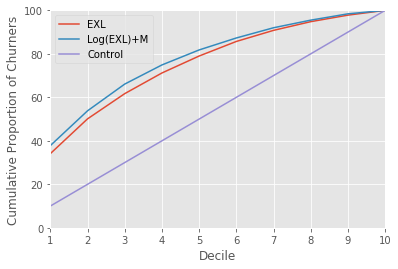

In [21]:
# poc: proportion of churn
poc_log = np.array([37.8, 53.8, 66.1, 74.9, 81.8, 87.3, 92.0, 95.5, 98.4, 100.0])
#poc_box = np.array([37.4, 53.7, 65.8, 74.7, 81.8, 87.3, 91.8, 95.5, 98.3, 100.0])
poc_exl = np.array([34.1, 50.1, 61.7, 71.2, 79.0, 85.7, 90.8, 94.8, 97.8, 100.0])
control = np.linspace(10,100,10)
decile =  np.linspace(1,10,10)
df = pd.DataFrame({'EXL': poc_exl, 'Log(EXL)+M': poc_log, 'Decile': decile, 'Control': control})
fig = df.plot(x='Decile', y=['EXL', 'Log(EXL)+M', 'Control'])
fig.set_xlabel('Decile')
fig.set_ylabel('Cumulative Proportion of Churners')
fig.set_ylim(0,100)
#fig.legend(labels=[y_set+' Data', 'Randomized Control'])

In [17]:
#path2fig  = "/path/to/project/Figures/"
#fileName = time.strftime("%Y-%m-%d") + "__EXL-vs-LogExl+M"
#fig.get_figure().savefig(path2fig+fileName+".png")

- - - - - - - - - -

## The NIF Variable
In the first entry to this journal, you will notice that the NIF variable by itself achieves less than 0.50 AUC.  It is by far the worst variable.  Question:  Would taking it out help matters?

Answer:  Wow.  It looks like the answer might be "yes."  


|            | EXL    | EXL6  | Log(EXL) | Log(EXL6) | Box(EXL) |Box(EXL6) |
|------------|--------|-------|----------|-----------|----------|----------|
| LR         | 0.05   | 0.05  | 0.05     |  0.05     | 0.05     | 0.05     | 
| Epochs     | 7      | 7     | 7        |  7        | 7        | 7        |
| Batch Size | 250    | 250   | 250      | 250       | 250      | 250      |
| Layer 1    |sig,1,5 |sig,1,5| sig,1,5  | sig,1,5   | sig,1,5  | sig,1,5  |
| Layer 2    | --     | --    | --       |  --       | --       | --       | 
|RO-AUC (AUC)| 73.9   | 73.6  | 74.8     | 74.6      | 74.8     | 74.5     |
| Accuracy   | 92.9   | 92.9  | 93.0     | 93.0      | 93.1     | 93.1     |
| Precision  | 39.7   | 40.8  | 57.2     | 60.3      | 67.0     | 67.2     |
| Recall     | 1.4    | 1.3   | 3.4      | 3.6       | 4.6      | 4.8      |
| PR-AUC     | 22.3   | 22.4  | 24.3     | 24.9      | 25.2     | 25.6     |
| F1 Score   | 2.8    | 2.6   | 6.5      | 6.8       | 8.6      | 9.0      |
| R2 Score   | 7.3    | 7.3   | 9.0      | 9.3       | 9.2      | 9.5      |
| MnAbsErr   | 11.8   | 11.8  | 11.8     | 11.7      | 11.5     | 11.5     |
| MnSqErr    | 6.1    | 6.1   | 5.9      | 6.0       | 6.0      | 6.0      |
| MedAbsErr  | 4.5    | 4.5   | 4.4      | 4.3       | 4.1      | 4.1      |

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

## Another look at varying the learning rate and number of epochs

The two tables below show: 
* Learning rate only has to be "small enough" to not have the training get stuck in local optima and no smaller.  In neither case below do we see a dramatic difference, though as a rule-of-thumb smaller LRs will require more epochs.
* The number of epoch only has to be so many --- any more adds nothing, and can actually being to detract from the model's predictive power.

|            | Log(EXL6) | Log(EXL6)\*|     EXL6  |     EXL6\* | EXL     |
|------------|-----------|------------|-----------|------------|---------|
| LR         |  0.05     |   0.01     |  0.05     |   0.01     | 0.01    |
| Epochs     |  7        |   10       |  7        |   10       | 10      |
| Batch Size | 250       |  250       | 250       |  250       | 250     |
| Layer 1    | sig,1,5   |  sig,1,5   | sig,1,5   |  sig,1,5   | sig,1,5 |
| Layer 2    | --        |  --        | --        |  --        | --      |
|RO-AUC (AUC)| 74.6      | 74.6       | 73.6      | 73.6       | 73.1    |
| Accuracy   | 93.0      | 93.0       | 92.9      | 92.9       | 93.0    |
| Precision  | 60.3      | 60.6       | 40.8      | 40.8       | 37.9    |
| Recall     | 3.6       | 3.5        | 1.3       | 1.3        | 1.3     |
| PR-AUC     | 24.9      | 24.9       | 22.4      | 22.4       | 21.0    |
| F1 Score   | 6.8       | 6.7        | 2.6       | 2.6        | 2.6     |
| R2 Score   | 9.3       | 9.3        | 7.3       | 7.3        | 6.6     |
| MnAbsErr   | 11.7      | 11.7       | 11.8      | 11.8       | 11.7    |
| MnSqErr    | 6.0       | 6.0        | 6.1       | 6.1        | 6.0     |
| MedAbsErr  | 4.3       | 4.2        | 4.5       | 4.5        | 4.4     |



## Gains Charts, Take 2:  EXL Model vs Crazy 66-Node HL Box(EXL)+F Model


Dave wanted to see the Gains charts of the original EXL logistic model, and the best "Urban Model."  Instead of running my best model, I thought this double-input hidden layer architecture w/ fortnights would work wonders.  It didn't.  The AUC is only 75.1 (nowhere near the 76.9 I used to get on the 57dts data set). Also the precision is down.  (That said, recall is up to 10.5, which might be one of the highest precisions I've seen.)  

Given so many nodes, I decided to tune down the learning rate to 0.01 (from my usual 0.05) and up the epoch to 10 (from my usual 7).  Given I used the 81dts data set and a higher-proportioned training set, this run took nearly all of Friday.  (If I had lowered the batch size, it probably would have!)  Since Dave was expecting to see a Gains Chart, I had to go with this one at first since it was the first run I had done with the Gains-Chart-related code written. This also put me in the position of having to re-run the EXL model since I'd used different hyperparameters (otherwise, differences in model performance could be wrongly associated with differences in hyperparameters).

On Friday night, I looked over my models and decided to run the Log(EXL)+M model with a 19-node hidden layer, which had scored 76.9 AUC on the 57dts data set.  On Saturday, I updated the Gains Charts for Dave.  I figured that there is no reason to throw out this information.  For example, this info shows that the Gains data and model scores are similar for test and validation sets, which is great.  


Learning Rate: 0.01,Number of Epochs: 10, Batch Size=250, Layer 1: 66-Node Sigmoid,
Layer 2: 1-Node Sigmoid (Output Layer), 

|            | EXL    | Box(EXL)+F|
|------------|--------|-----------|
| LR         |  0.01  | 0.01|
| # Epochs   |  10    | 10  |
| Batch Size |  250   | 250 |
| Layer 1    | sig,1,5|sig,66,3|
| Layer 2    | --     | sig,1,5|
| AUROC (AUC)|   73.1 | 75.1|
| Accuracy   |   93.0 | 93.2|
| Precision  |   37.9 | 56.4|
| Recall     |   1.3  | 10.5|
| AUPRC      |   21.0 | 25.6|
| F1 Score   |   2.6  | 17.7|
| R2 Score   |   6.6  | 9.5 |
| MnAbsErr   |   11.7 | 11.5|
| MnSqErr    |   6.0  | 5.9 |
| MedAbsErr  |   4.4  | 4.3 |


Columns with multiple values (a,b) represent values from the validation and test sets, respectively.

|decile|size |num_churn    |churn_rate |all_churn   |proportion_of_churn|cum_prop      |cum_control|
|------|-----|-------------|-----------|------------|-------------------|--------------|-----------|
|0	   |16012|	3708, 3827 | 23.2, 23.9|11131, 11306|33.31, 33.85       |33.31, 33.85  |10.0       |
|1	   |16011|	1766, 1828 | 11.0, 11.4|11131, 11306|15.87, 16.17       |49.18, 50.02  |20.0       |
|2	   |16011|	1260, 1384 | 7.9,  8.6 |11131, 11306|11.32, 12.24       |60.50, 62.26  |30.0       |
|3	   |16011|	1101, 1064 | 6.9,  6.6 |11131, 11306|9.89,  9.41        |70.39, 71.67  |40.0       |
|4	   |16011|	897, 892   | 5.6,  5.6 |11131, 11306|8.06,  7.89        |78.45, 79.56  |50.0       |
|5	   |16011|	726, 752   | 4.5,  4.7 |11131, 11306|6.52,  6.65        |84.97, 86.21  |60.0       |
|6	   |16011|	607, 580   | 3.8,  3.6 |11131, 11306|5.45,  5.13        |90.42, 91.34  |70.0       |
|7	   |16011|	469, 427   | 2.9,  2.7 |11131, 11306|4.21,  3.78        |94.63, 95.12  |80.0       |
|8	   |16011|	386, 329   | 2.4,  2.1 |11131, 11306|3.47,  2.91        |98.10, 98.03  |90.0       |
|9	   |16011|	211, 223   | 1.3   1.4 |11131, 11306|1.90,  1.97        |100.00, 100.00|100.0      |

|decile|size |num_churn   |churn_rate |all_churn   |proportion_of_churn|cum_prop      |cum_control|
|------|-----|------------|-----------|------------|-------------------|--------------|-----------|
|0	   |16012|	4028.0, \* | 25.2, 25.6|11131, 11306|36.19, 33.6        |36.19, \*      |10.0       |
|1	   |16011|	1859.0, \* | 11.6, 11.9|11131, 11306|16.70, 16.79       |52.89, \*      |20.0       |
|2	   |16011|	1376.0, \* | 8.6, 8.5  |11131, 11306|12.36, 11.97       |65.25, \*      |30.0       |
|3	   |16011|	1010.0, \* | 6.3, 6.9  |11131, 11306|9.07,  9.70        |74.32, \*      |40.0       |
|4	   |16011|	807.0, \*  | 5.0, 5.2  |11131, 11306|7.25,  7.36        |81.57, \*      |50.0       |
|5	   |16011|	619.0, \*  | 3.9, 3.8  |11131, 11306|5.56,  5.34        |87.13, \*      |60.0       |
|6	   |16011|	562.0, \*  | 3.5, 3.3  |11131, 11306|5.05,  4.66        |92.18, \*      |70.0       |
|7	   |16011|	424.0, \*  | 2.6, 2.4  |11131, 11306|3.81,  3.40        |95.99, \*      |80.0       |
|8	   |16011|	304.0, \*  | 1.9, 2.1  |11131, 11306|2.73,  3.03        |98.72, \*      |90.0       |
|9	   |16011|	142.0, \*  | 0.9, 1.0  |11131, 11306|1.28,  1.45        |100.00, \*     |100.0      |

\* forgot to record test values


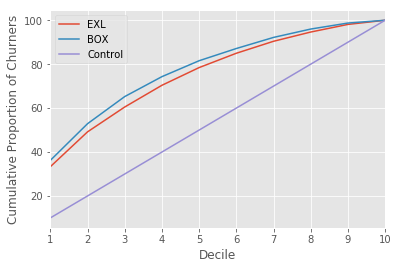

In [8]:
poc_exl = np.array([33.31, 15.87, 11.32, 9.89, 8.06, 6.52, 5.45, 4.21, 3.47, 1.90]).cumsum()
poc_box = np.array([36.19, 16.70, 12.36, 9.07, 7.25, 5.56, 5.05, 3.81, 2.73, 1.28]).cumsum()
control = np.linspace(10,100,10)
decile =  np.linspace(1,10,10)
df = pd.DataFrame({'EXL': poc_exl, 'BOX': poc_box, 'Decile': decile, 'Control': control})
fig = df.plot(x='Decile', y=['EXL', 'BOX', 'Control'])
fig.set_xlabel('Decile')
fig.set_ylabel('Cumulative Proportion of Churners')
#fig.legend(labels=[y_set+' Data', 'Randomized Control'])

In [11]:
#path2fig  = "/path/to/project/Figures/"
#fileName = time.strftime("%Y-%m-%d") + "__EXL-vs-2LayerBox"
#fig.get_figure().savefig(path2fig+fileName+".png")

- - - - - - - - - - 
# 2017-04-12/13
- - - - - - - - - - 

On Wednesday, I began testing out the Box-Cox transformation, which is a way of examining
a data distribution, and assessing what type of transformation will approximately
normalize that distribution.  The logarithm is a special case of the Box-Cox
transformation, and is often used as a "good enough" approach for highly-skewed
data distributions. 

The ultimate bottleneck is runtime:  the last 3 models presented took 3-4 hours each
(the last one having to be run on Thursday).

I reprint the non-transformed, 7-variable EXL results and the log-transformed, 7-variable
EXL results here for contrast. 

**The Important Takeaway**:
As we already know, log-transforming all 7 EXL variables gives an extra percentage point of RO-AUC for free (no additional variables necessary).  Additionally, this log-transformation increases the model's precision by 17.5 points, recall by 2 points, PR-AUC by 2 points, F1 score by 3.7 points, and R2 score by 1.7 points; and we see a decrease in overall errors.  If this free performance boost isn't already impressive enough, the Box-Cox transformation takes us to yet another level, providing nearly 10 additional precision points, and an extra 1-2 points of recall, PR-AUC, and F1.

### Just the EXL Variables

|            | EXL    |Log(EXL)  |Box(EXL)  |
|------------|--------|----------|----------|
| LR         | 0.05   | 0.05     | 0.05     |
| Epochs     | 7      | 7        | 7        |
| Batch Size | 250    | 250      | 250      |
| Layer 1    |sig,1,5 | sig,1,5  | sig,1,5  |
| Layer 2    | --     | --       | --       |
|RO-AUC (AUC)| 73.9   | 74.8     | 74.8     |
| Accuracy   | 92.9   | 93.0     | 93.1     |
| Precision  | 39.7   | 57.2     | 67.0     |
| Recall     | 1.4    | 3.4      | 4.6      |
| PR-AUC     | 22.3   | 24.3     | 25.2     |
| F1 Score   | 2.8    | 6.5      | 8.6      |
| R2 Score   | 7.3    | 9.0      | 9.2      |
| MnAbsErr   | 11.8   | 11.8     | 11.5     |
| MnSqErr    | 6.1    | 5.9      | 6.0      |
| MedAbsErr  | 4.5    | 4.4      | 4.1      |


### The EXL Variables w/ Months
|            | EXL+M  |Log(EXL)+M|Box(EXL)+M|
|------------|--------|----------|----------|
| LR         | 0.05   | 0.05     | 0.05     |
| Epochs     | 7      | 7        | 7        |
| Batch Size | 250    | 250      | 250      |
| Layer 1    |sig,1,5 | sig,1,5  | sig,1,5  |
| Layer 2    | --     | --       | --       |
|RO-AUC (AUC)|    |      |      |
| Accuracy   |    |      |      |
| Precision  |    |      |      |
| Recall     |     |       |       |
| PR-AUC     |    |      |      |
| F1 Score   |     |       |       |
| R2 Score   |     |       |       |
| MnAbsErr   |    |      |      |
| MnSqErr    |     |       |       |
| MedAbsErr  |     |       |       |

EXL+M
AUROC (AUC):  73.3
Accuracy:     93.0
Precision:    40.5
Recall:       1.5
AUPRC:        21.1
F1 Score:     2.9
R2 Score:     6.6
MnAbsErr:     11.7
MnSqErr:      6.0
MedAbsErr:    4.3

Log(EXL)+M (7,14 Epochs)
AUROC (AUC):  74.8
Accuracy:     93.1
Precision:    52.7, 53.7
Recall:       3.1,  4.0
AUPRC:        23.5
F1 Score:     5.9,  7.5
R2 Score:     8.6,  8.5
MnAbsErr:     11.6, 11.9
MnSqErr:      5.9,  5.9
MedAbsErr:    4.2,  4.5

Box(EXL)+M (7,14 Epochs)
AUROC (AUC):  74.6
Accuracy:     93.2
Precision:    65.2, 65.5
Recall:       4.7
AUPRC:        24.4
F1 Score:     8.7
R2 Score:     8.8
MnAbsErr:     11.5, 11.4
MnSqErr:      5.9
MedAbsErr:    4.0



### The EXL Variables w/ Fortnights


|Box(EXL)+M|Log(EXL)+F|
|----------|----------|
| 0.05     | 0.05     |
| 7        | 10       |
| 75       | 125      |
| sig,38,3 | sig,33,3 |
| sig,1,5  | sig,1,5  |
| 75.7     | 76.2     |
| 93.2     | 93.2     |
| 63.5     | 61.6     |
| 10.0     | 9.7      |
| 27.8     | 27.8     |
| 17.2     | 16.7     |
| 10.9     | 11.1     |
| 11.5     | 11.3     |
| 5.8      | 5.8      |
| 4.4      | 4.2      |

EXL+F
AUROC (AUC):  73.9
Accuracy:     93.0
Precision:    41.9
Recall:       1.6
AUPRC:        21.4
F1 Score:     3.0
R2 Score:     6.9
MnAbsErr:     11.5
MnSqErr:      6.0
MedAbsErr:    4.2
 
Log(EXL)+F
AUROC (AUC):  75.3
Accuracy:     93.1
Precision:    56.5
Recall:       3.4
AUPRC:        23.9
F1 Score:     6.5
R2 Score:     8.9
MnAbsErr:     11.4
MnSqErr:      5.9
MedAbsErr:    4.1

Box(EXL)+F
AUROC (AUC):  75.1
Accuracy:     93.2
Precision:    65.7
Recall:       5.0
AUPRC:        24.8
F1 Score:     9.3
R2 Score:     9.1
MnAbsErr:     11.4
MnSqErr:      5.9
MedAbsErr:    4.1

Box(EXL)+F+HL



- - - - -
Note:  I checked batch size again.  Yes, the results suffer for greater batch size, but the runtime also decreases quite a bit.

Box(EXL)+F  (1000 bs)
AUROC (AUC):  75.1
Accuracy:     93.2
Precision:    65.7
Recall:       5.0
AUPRC:        24.8
F1 Score:     9.3
R2 Score:     9.1
MnAbsErr:     11.4
MnSqErr:      5.9
MedAbsErr:    4.1

Box(EXL)+F  (250 bs)
AUROC (AUC):  75.0
Accuracy:     93.2
Precision:    65.5
Recall:       4.9
AUPRC:        24.8
F1 Score:     9.1
R2 Score:     9.1
MnAbsErr:     11.4
MnSqErr:      5.9
MedAbsErr:    4.0


- - - - - - - - - - 
# 2017-04-10/11
- - - - - - - - - - 

### Quick Note:  Code Clean-Up
Had to clean up the code quite a bit to start accepting arbitrary amounts of new variables.  For example, instead of using NumPy arrays, I am now using Pandas DataFrames, which allow features to be subset by name rather than index.  This is important because of the introduction of many new variables: instead of tracking which column index each var is in, I only have to have an index of column names.   One issue with Pandas DataFrames is that it seems to up the run time.  A solution to this is converting them to NumPy arrays right before injecting them into the neural network (after the DataFrame has provided its key utilities in the data prep sections).

The new and old versions of the code are both saved in the project folder.

### Quick Note:  Pandas DataFrames vs NumPy Arrays
One setback of DataFrames seems to be that they're slower than NumPy arrays.  This is easily resolved:
just before inputting the final DataFrame (df) into the neural net, instead use df.values, which is
the underlying NumPy array.

### Recalibration

* EXL: Just EXL Vars
* Log(EXL): Just the Log(EXL) Vars
* Log(EXL)+F: Log(EXL) w/ Fortnight Vars
* Log(EXL)+R: Log(EXL) w/ Rebuffering Ratio Var
* Layer X: activation function, number of nodes, randomization seed

|             | EXL   | Log(EXL) |Log(EXL)+F|Log(EXL)+R|
|-------------|-------|----------|----------|----------|
| LR          | 0.05  | 0.05     | 0.05     | 0.05     |
| Epochs      | 7     | 7        | 7        | 7        |
| Batch Size  | 250   | 250      | 250      | 250      |
| Layer 1     |sig,1,5| sig,1,5  | sig,1,5  | sig,1,5  |
| Layer 2     | --    | --       | --       | --       |
| AUROC (AUC) | 73.9  | 74.8     | 76.0     | 74.8     |
| Accuracy    | 92.9  | 93.0     | 93.0     | 93.0     |
| Precision   | 39.7  | 57.2     | 56.7     | 56.5     | 
| Recall      | 1.4   | 3.4      | 3.5      | 3.5      | 
| AUPRC       | 22.3  | 24.3     | 24.7     | 24.3     | 
| F1 Score    | 2.8   | 6.5      | 6.6      | 6.7      | 
| R2 Score    | 7.3   | 9.0      | 9.3      | 9.0      | 
| MnAbsErr    | 11.8  | 11.8     | 11.5     | 11.9     | 
| MnSqErr     | 6.1   |  5.9     | 5.9      | 5.9      | 5.8         |
| MedAbsErr   | 4.5   | 4.4      | 4.1      | 4.5      | 4.2         |


#### Note to Self:
Format numbers and strings in Python:
https://pyformat.info/


- - - - - - - - - - 
# 2017-04-05
- - - - - - - - - - 

**Number of Nodes at Each Layer**:  For yesterday's runs, I did not explicitly document the number of nodes used at each layer.  To clarify, any time a single hidden layer was used, that layer had 5 nodes;  any time two hidden layers were used, the layers had 5 and 3 nodes, respectively.  The output layer is always a single node which decides between 0 or 1.


### Properly-Defined Big4 Variables
I was wrong about the newly-defined Big4 vars yesterday, when I was accidentally only using 3 of the Big4 vars.  When using all four Big4 vars, the model performance is actually pretty good.  Below I contrast the 2-layer sigmoid-sigmoid version of this variable combo w/ the 2-layer sigmoid-sigmoid runs from yesterday.


|                        |Log(EXL)+B4+Months|Log(EXL)+Months|Log(EXL)+B4    | 
|------------------------|------------------|---------------|---------------|
| Learning Rate          | 0.05            | 0.05          | 0.05          |
| Number of Epochs       | 7               | 7             | 7             |
| Batch Size             | 250             | 250           | 250           |
| FCL1: Activation, Seed | sig,3           | sig,3         | sig,2         |
| FCL2: Activation, Seed | sig,5           | sig,5         | sig,5         |
| FCL3: Activation, Seed | ---             | ---           | ---           |
| AUROC (AUC)            | 76.6            | 76.5          | 76.0          |
| Accuracy               | 93.5            | 93.5          | 93.4          |
| Precision              | 61.8            | 61.2          | 64.5          |
| Recall                 | 10.0            | 10.1          | 8.3           |
| AUPRC                  | 27.4            | 27.2          | 27.3          |
| F1 Score               | 17.3            | 17.4          | 14.7          |
| R2 Score               | 11.2            | 11.1          | 10.9          |
| MnAbsErr               | 11.3            | 11.2          | 11.0          |
| MnSqErr                | 5.6             | 5.6           | 5.7           |
| MedAbsErr              | 4.4             | 4.3           | 4.1           |


## 52 Weeks
I tried running the model w/ weekly dummy vars, however (1) a single run takes upwards of 40 minutes, and (2) it seems we do not use enough data to support so many feature vars (or, at the least, using so many feature vars requires many more epochs, which would be 2+ hours for each run).  Running on an AWS supercomputer would help here!

## 26 Fortnights
These runs took a while, but it was tolerable.  Also, the model was able to learn with reduced feature set. Months might be better than Fortnights due to the smaller number of variables.  If fortnights are inherently better, this could be extracted by performing PCA on the variables, and only inputting a small amount into the model.

|                               | M1      | M2      | M2\*   | M3      | M4      |
|-------------------------------|---------|---------|--------|---------|---------|
| Learning Rate                 | 0.05    | 0.05    | 0.05   | 0.05    | 0.05    |
| Number of Epochs              | 7       | 7       | 14     | 7       | 7       |
| Batch Size                    | 250     | 250     | 250    | 250     | 250     |
| FCL1: Activation, Nodes, Seed | sig,1,3 | sig,5,3 | sig,5,3| sig,12,2| sig,33,2|
| FCL2: Activation, Nodes, Seed | ---     | sig,1,5 | sig,1,5| sig,1,5 | sig,1,5 |
| FCL3: Activation, Nodes, Seed | ---     | ---     | ---    | ---     | ---     |
| AUROC (AUC)                   | 76.4    | 76.6    | 76.7   | 76.7    | **76.9**    |
| Accuracy                      | 93.3    | 93.4    | 93.4   | 93.5    | 93.5    |
| Precision                     | 56.2    | 64.0    | 64.2   | 63.2    | 62.0    |
| Recall                        | 3.9     | 5.3     | 6.6    | 8.1     | **10.5**    |
| AUPRC                         | 25.2    | 27.1    | 27.4   | 27.7    | 28.1    |
| F1 Score                      | 7.3     | 9.9     | 11.9   | 14.3    | 17.9    |
| R2 Score                      | 9.8     | 10.8    | 11.0   | 11.4    | 11.5    |
| MnAbsErr                      | 11.1    | 11.0    | 10.8   | 11.0    | 11.6    |
| MnSqErr                       | 5.7     | 5.6     | 5.6    | 5.6     | 5.6     |
| MedAbsErr                     | 4.0     | 4.0     | 4.1    | 3.8     | 4.7     |


# More Nodes / Different Optimizers
Clearly, using more nodes helped in the last model recorded above.  However, the run took about 40 minutes.  Maybe if we use months (which performed similarly), we can cut down on the run time.  Also, I'm interested in whether  optimizers other than Adam will help improve model performance.  Here I look at Gradient Descent and Gradient Descent w/ Momentum (where momentum is set to 0.9).

|                              |          |          |          |          |
|------------------------------|----------|----------|----------|----------| 
|optimizer                     | adam     | adam     | gradDesc | mom(0.9) |
|FCL1: Activation, Nodes, Seed | sig,38,2 | sig,19,2 | sig,19,2 | sig,19,2 |
|FCL2: Activation, Nodes, Seed | sig,1,5  | sig,1,5  | sig,1,5  | sig,1,5  |
|AUROC (AUC)                   | 76.7     | **76.9**     | 62.9     | 75.8     |
|Accuracy                      | 93.5     | 93.5     | 93.2     | 93.3     |
|Precision                     | 62.3     | 64.0     | 0.0      | 65.9     |
|Recall                        | 11.3     | 10.2     | 0.0      | 1.2      |
|AUPRC                         | 28.1     | 28.4     | 13.0     | 24.4     |
|F1 Score                      | 19.1     | 17.5     | 0.0      | 2.3      |


* More nodes did increase AUC when using monthly dummies, but only 76.6 -> 76.7; fortnights get up to 76.9
* Whoa... Regular gradient descent is terrible.  
* Momentum certainly helps gradient descent, but still not nearly as good as using Adam|




- - - - - - - - - - 
# 2017-04-04
- - - - - - - - - - 


Executive Summary:  We have solidly achieved 76.6 RO-AUC.  


### 7 Log(EXL) Vars + Month Dummies + New Big4

|      Model             | M1   |  M2  |  M3  |  M4   |  M5   |   M6  |   M7  |
|------------------------|------|------|------|-------|-------|-------|-------|
| Learning Rate          | 0.05 | 0.05 | 0.05 | 0.05  | 0.05  |  0.05 |  0.05 |
| Number of Epochs       | 7    | 7    | 7    | 7     | 7     |  7    |  7    |
| Batch Size             | 250  | 250  | 250  | 250   | 250   |  250  |  250  |
| FCL1: Activation, Seed | sig,5| sig,3| sig,2| sig,3 | relu,3| tanh,3| tanh,3|
| FCL2: Activation, Seed | ---  | sig,5| sig,3| relu,5| sig,5 | sig,5 | tanh,5|
| FCL3: Activation, Seed | ---  | ---  | sig,5| ---   | ---   | ---   | ---   |
|                        |      |      |      |      |      |      |      |
|     **Model**          |**M1**|**M2**|**M3**|**M4**|**M5**|**M6**|**M7**|
| AUROC (AUC)            | 76.0 | 76.6 | 76.5 | 50.0 | 50.0 | 76.1 | 76.5 |
| Accuracy               | 93.3 | 93.5 | 93.5 | 93.3 | 93.3 | 93.4 | 93.5 |
| Precision              | 55.7 | 61.8 | 62.6 | 0.0  | 0.0  | 58.5 | 59.5 |
| Recall                 | 3.9  | 10.0 | 10.0 | 0.0  | 0.0  | 6.6  | 9.6  |
| AUPRC                  | 24.7 | 27.4 | 27.4 | 53.4 | 53.4 | 25.9 | 26.8 |
| F1 Score               | 7.3  | 17.3 | 17.3 | 0.0  | 0.0  | 11.9 | 16.6 |
| R2 Score               | 9.5  | 11.2 | 11.2 | -7.2 | -7.2 | 10.2 | 10.4 |
| MnAbsErr               | 11.2 | 11.3 | 11.1 | 6.7  | 6.7  | 11.5 | 12.5 |
| MnSqErr                | 5.7  | 5.6  | 5.6  | 6.7  | 6.7  | 5.6  | 5.6  |
| MedAbsErr              | 4.1  | 4.4  | 4.2  | 0.0  | 0.0  | 4.0  | 5.6  |


Note \#1:  M3 would probably perform as good as (or better) than M2 with more epochs.  Likely not too much better.  To explore this (and more complex architectures), it would be helpful to have an AWS account where I can start/stop/terminate a g2.2xlarge on Linux w/ CUDA tools, TensorFlow, and Python3 pre-installed.

Note \#2:  Seems odd that M4 and M5 performed exactly the same.

Note \#3:  Further exploration on this variable set could include exploring tanh and sigmoid layers, varying the number of nodes on the second layer of the 2-layer models, switching out the loss function, and/or changing the optimizer.



### 7 Log(EXL) Vars + Month Dummies
|      Model             | M8   |  M9  |  M10 |   M11 |   M12 |
|------------------------|------|------|------|-------|-------|
| Learning Rate          | 0.05 | 0.05 | 0.05 |  0.05 |  0.05 |
| Number of Epochs       | 7    | 7    | 7    |  7    |  7    |
| Batch Size             | 250  | 250  | 250  |  250  |  250  |
| FCL1: Activation, Seed | sig,5| sig,3| sig,2| tanh,3| tanh,3|
| FCL2: Activation, Seed | ---  | sig,5| sig,3| sig,5 | tanh,5|
| FCL3: Activation, Seed | ---  | ---  | sig,5| ---   | ---   |
|                        |      |      |      |      |      |
|     **Model**          |**M8**|**M9**|**M10**|**M11**|**M12**|
| AUROC (AUC)            | 76.0 | 76.5 | **76.6** | 76.3 | 76.4 |
| Accuracy               | 93.3 | 93.5 | 93.5 | 93.5 | 93.5 |
| Precision              | 56.2 | 61.2 | 60.9 | **64.8** | 61.6 |
| Recall                 | 3.9  | 10.1 | **10.6** | 5.9  | 9.7  |
| AUPRC                  | 24.7 | 27.2 | **27.6** | 27.0 | 27.0 |
| F1 Score               | 7.3  | 17.4 | **17.9** | 10.8 | 16.8 |
| R2 Score               | 9.5  | 11.1 | **11.2** | 10.8 | 10.9 |
| MnAbsErr               | 11.2 | 11.2 | **11.4** | 11.1 | 11.3 |
| MnSqErr                | **5.7**  | 5.6  | 5.6  | 5.6  | 5.6  |
| MedAbsErr              | 4.1  | 4.3  | **4.6**  | 3.9  | 4.4  |


### 7 Log(EXL) Vars + New Big4
Still looks to be bad performance w/ the newly-defined Big4 vars... However, I only had time to run a logistic regression.  There could be something there to record for the future's sake.

### AWS
Each model run takes anywhere from 7-15 minutes easy, depending on how many feature vars are used, how many nonlinearities are introduced in the network layers, and how many nodes I place in each layer.  Using a g2.x2large w/ an Amazon Machine Image (AMI) for a linux computer that comes stock with CUDA tools, Python3, and TensorFlow GPU software, we could certainly explore the parameter space much more rapidly.  

Our current AWS set-up is overly-complicated.  I can go to Amazon right now, spin up a g2.x2large w/ the right AMI, and be rockin' and rollin'.  Each day might cost us ~5-8 dollars.  Since I only get to work on the model 2-3 days/wk, we are talking about ~15-25 dollars per week.  



__________________________________

General Note: 

Some metrics require that prediction be mapped to classes, e.g., here I've used
y_class := y_pred > 0.5 (note that y_pred > 0.3 works better for many metrics...)


- - - - - - - - - - 
# 2017-03-28
- - - - - - - - - - 

#### Executive Summary:
1. To better understand the relative importance of churn model parameters that EXL had identified, I first ran a logistic regression on each of the 7 variables individually   
    * pmt_pct_days_paid (ppd) w/ AUC=68.6
    * pct_ppv1 (ppv) w/ AUC=60.2
    * num_vol_losses (nvl) w/ AUC=59.2
    * vod_lst_30days (vod30d) w/ AUC=58.8
    * nxt_view_ep_lst_90days (nxt30d) w/ AUC=57.9
    * no_view_90days_flag (nv90d) w/ AUC=54.5
    * num_invol_fail (nif) w/ AUC=49.0    
2. Having identified ppd, ppv, and nvl as giving the highest AUCs, I then combined them in various ways and computed 4 additional logistic regressions: 
    * (ppd,ppv,nvl) w/ AUC=72.2
    * (ppd,nvl) w/ AUC=71.3
    * (ppd,ppv) w/ AUC=69.6
    * (ppd,nvl) w/ AUC=65.2
3. Seasonal "Big 4" variables were investigated.  However, unfortunatley I defined them in a manner that turns out to be better-suited for a winback model: Is Big4 event X within the next 30 days? (On a later date, I will redefine these "Big 4" variables to answer "Was Big4 event X within the last 30 days?")
    * As currently defined, the Big4 variables do not contribute to the AUC when combined with the EXL variables.
    * If anything, incorporating these values makes the learning process harder and can cause lower AUCs for the same number of epochs used to train the model.
    * Using these ill-defined Big4 variables in isolation gives an AUC of 51.4, which is bad, but still better than the nif variable in isolation.
    * One thing that might be helpful is the realization that a variable might not improve the AUC, but does improve other model metrics.
4. Variable Transformation: Nudged Logarithms
    * For the continuous variables with high skew, a logarithm can help tame the distribution 
    * Since our variables have a minimum of 0, we add 1 ("nudge") to the raw values before taking the logarithm, resulting in a new distribution with a minimum of 0
    * First I looked at single-variable modifications.  For 6 of 7 of these models, the AUC was slightly improved, taking values in the range (74.0,74.5).  However, taking the log of the nif variable simply maintained the AUC at 73.9.
    * Great News:  When taking the logarithm of all the skewed, continuous variables, we achieve an AUC of 74.9%, which is a percentage point higher than not doing so (73.9%).

**Analysis**:  

The results from step 2 suggest that most of the information contained in ppv is already contained in ppd: though nvl by itself generated a lower AUC than ppv, the (ppd,nvl) pair scores almost 2% higher than (ppd,ppv).  The triplet of the variables gets another percentage point higher, landing at 72.2%.  Note that including the 4 additional variables only increase this to 73.9%.  Given a solo AUC of 49.0, the nif variable likely contributes little-to-nothing to the 7-variable AUC (and might even be a learning depressant).  The Big4 vars, as defined herein, do not contribute to the AUC (however, properly defined Big4 vars must be addressed going forward).  Most importantly, simply taking logarithms of our highly-skewed, continuous variables improves the AUC by 1%.

**Going Forward**: 

* At one point I should look at removing the nif variable.
* Properly define Big4 vars and assess the situation.
* Reciprocal transformations are also known to help tame highly-skewed variables, and so is something I should try as well.


- - - - - - - - - -

## The Details

* \* = no predictions, so set to zero by default
* y_class := y_pred > 0.5 (note that y_pred > 0.3 works better for many metrics...)
* Loss Function:  MSE
* Optimizer: Adam


### Single EXL Vars 


| LR  | Epochs | Batch |   Vars    | AUROC |  Acc | Prec | Recall | AUPRC |  F1  |
|-----|--------|-------|-----------|-------|------|------|--------|-------|------|
| 0.1 |    4   |  512  | nvl       | 59.2  | 93.1 | 24.2 |  1.3   | 16.4  |  2.5 |
| 0.1 |    4   |  512  | ppd       | 68.6  | 93.2 |  0\* |   0.0  | 14.3  |  0\* |
| 0.1 |    4   |  512  | ppv       | 60.2  | 93.3 |  0\* |   0.0  | 33.9  |  0\* |
| 0.1 |    4   |  512  | nif       | 49.0  | 93.3 |  0\* |   0.0  |  6.9  |  0\* |
| 0.1 |    4   |  512  | nv90d     | 54.5  | 93.3 |  0\* |   0.0  | 18.3  |  0\* |
| 0.1 |    4   |  512  | vod30d    | 58.8  | 93.3 |  0\* |   0.0  | 27.7  |  0\* |
| 0.1 |    4   |  512  | nxt90d    | 57.9  | 93.3 |  0\* |   0.0  | 37.7  |  0\* |


### Several EXL Vars 


| LR  | Epochs | Batch |   Vars    | AUROC |  Acc | Prec | Recall | AUPRC |  F1  |
|-----|--------|-------|-----------|-------|------|------|--------|-------|------|
| 0.1 |    4   |  512  | ppd, ppv    | 69.6  | 93.3 |  0\* |   0.0  | 15.0  |  0\* |
| 0.1 |    4   |  512  | ppd, nvl    | 71.3  | 93.2 | 32.7 |   0.7  | 17.9  |  1.4 |
| 0.1 |    4   |  512  | ppv, nvl    | 65.2  | 93.2 | 29.7 |   0.9  | 16.5  |  1.8 |
| 0.1 |    4   |  512  | ppd,ppv,nvl | 72.2  | 93.2 | 36.1 |   1.0  | 19.1  |  1.9 |



### Several EXL Vars w/ B4


| LR   | Epochs | Batch |   Vars       | AUROC |  Acc | Prec | Recall | AUPRC |  F1  |
|------|--------|-------|--------------|-------|------|------|--------|-------|------|
| 0.1  |    4   |  512  | ppd,ppv,nvl,B4 | 71.1  | 93.3 | 48.5 |   0.2  | 18.5  |  0.3 |
| 0.01 |    4   |  512  | ppd,ppv,nvl,B4 | 68.0  | 93.3 | 0\*  |   0    | 13.1  |  0\* |
| 0.01 |   10   |  512  | ppd,ppv,nvl,B4 | 69.6  | 93.3 | 0    |   0    | 16.6  |  0   |
| 0.05 |   10   |  512  | ppd,ppv,nvl,B4 | 72.2  | 93.2 | 33.0 |   0.8  | 19.0  |  1.5 |
| 0.05 |   20   |  512  | ppd,ppv,nvl,B4 | 72.2  | 93.2 | 35.5 |   1.0  | 19.2  |  1.9 |


Will it help to take out B4?

| LR   | Epochs | Batch |   Vars       | AUROC |  Acc | Prec | Recall | AUPRC |  F1  |
|------|--------|-------|--------------|-------|------|------|--------|-------|------|
| 0.05 |    20   |  512  | ppd,ppv,nvl | 72.2  | 93.2 | 36.1 |   1.0  | 19.1  |  1.9 |
| 0.05 |    20   |   32  | ppd,ppv,nvl | 72.2  | 93.2 | 35.8 |   1.0  | 19.1  |  1.9 |
| 0.05 |    20   | 2000  | ppd,ppv,nvl | 70.4  | 93.3 | 40.0 |   1.0  | 18.0  |  0.0 |

Whoa... It's exactly the same.  So the B4 vars truly just make it harder to learn. Also, smaller batch sizes help quite a bit!


### Just the Big 4       


| LR   | Epochs | Batch |   Vars       | AUROC |  Acc | Prec | Recall | AUPRC |  F1  |
|------|--------|-------|--------------|-------|------|------|--------|-------|------|
| 0.05 |    12   | 500  | Big4         | 51.4  | 93.3 | 0\*  |   0    | 14.3  |  0\* |

It's not too good!


### All 7 EXL Vars       


| LR   | Epochs | Batch |   Vars       | AUROC |  Acc | Prec | Recall | AUPRC |  F1  |
|------|--------|-------|--------------|-------|------|------|--------|-------|------|
| 0.05  |   12   |  500  |   EXL   | 73.9  | 93.2 | 45.2 |  1.9   | 21.1  | 3.7 |
| 0.05  |   20   |  500  |   EXL   | 73.9  | 93.2 | 46.3 |  2.0   | 21.2  | 3.8 |
| 0.05  |   40   |  500  |   EXL   | 73.9  | 93.2 | 46.3 |  2.0   | 21.2  | 3.9 |
| 0.005 |   10   |  500  |   EXL   | 70.9  | 93.2 |   0  |   0    | 17.5  |  0  |
| 0.005 |   20   |  500  |   EXL   | 73.6  | 93.3 | 40.8 |  1.0   | 20.9  |  1.6  |


### All 7 EXL Vars + Big 4


| LR    | Epochs | Batch |   Vars  | AUROC |  Acc | Prec | Recall | AUPRC |  F1  |
|------|--------|-------|--------------|-------|------|------|--------|-------|------|
| 0.01  |   12   |  500  |   EXL   | 72.5  | 93.3 | 77.3 |  0.2   | 19.9  | 0.3  |
| 0.05  |   12   |  500  |   EXL   | 74.0  | 93.2 | 44.6 |  19.4  | 21.2  | 3.7  |
| 0.05  |   24   |  500  |   EXL   | 73.9  | 93.2 | 44.9 |  19.5  | 21.3  | 3.7  |

Big 4 vars do not help much, but they do improve recall (recall = tp/[tp+fn]: ability to detect all events). There are no real improvements past 12 or so epochs.

### EXL Single-Variable Log Modifications & B4 


In these cases, we modify only a single EXL, non-binary variable: var -> log(var+1).

| LR    | Epochs | Batch |   Vars  | Log  | AUROC |  Acc | Prec | Recall | AUPRC |  F1  | 
|-------|--------|-------|---------|------|-------|------|------|--------|-------|------|
| 0.05  |   12   |  500  |   EXL   | nvl  | 74.4  | 93.3 | 50.9 |  2.5   | 22.2  | 4.7  |
| 0.05  |   24   |  500  |   EXL   | nvl  | 74.3  | 93.3 | 50.9 |  2.5   | 22.4  | 4.8  |
| 0.05  |   15   |  500  |   EXL   | ppd  | 74.5  | 93.2 | 44.3 |  2.2   | 22.1  | 4.3  |
| 0.05  |   30   |  500  |   EXL   | ppd  | 74.5  | 93.2 | 44.4 |  2.3   | 22.1  | 4.3  |
| 0.05  |   15   |  500  |   EXL   | ppv  | 74.0  | 93.2 | 45.3 |  2.0   | 22.3  | 3.7  |
| 0.05  |   15   |  500  |   EXL   | nif  | 73.9  | 93.2 | 45.0 |  2.0   | 22.2  | 3.8  |
| 0.05  |   15   |  500  |   EXL   | vod  | 74.0  | 93.2 | 45.1 |  2.0   | 21.3  | 3.7  |

Again, first two variables I explored show that there are no real improvements past 12 or so epochs. So for remaining single-var cases, I just look at 15 epochs.  All single-variable modifications improve the model by a little bit.  Next, we will look at all the EXL non-binary variables tranformed this way simultaneously.


### Singly-modified EXL Vars w/ B4


In these cases, we modify only a single EXL, non-binary variable: var -> log(var+1).

| LR    | Epochs | Batch |   Vars  | Log  | AUROC |  Acc | Prec | Recall | AUPRC |  F1  |
|-------|--------|-------|---------|------|-------|------|------|--------|-------|------|
| 0.05  |   12   |  500  |   1 Log(EXL) + 6 EXL + B4  | nvl  | 74.9  | 93.3 | 54.4 |  3.6   | 23.6  | 4.2  |

#### Take note:  we have achieved 74.9 AUROC.  EXL's validation set gets 73.6.  



### EXL Log Vars      


In these cases, we modify only a single EXL, non-binary variable: var -> log(var+1).  Big4 vars are not included this time.  

| LR    | Epochs | Batch |   Vars  | Log  | AUROC |  Acc | Prec | Recall | AUPRC |  F1  | 
|-------|--------|-------|---------|------|-------|------|------|--------|-------|------|
| 0.05  |   12   |  500  | Log(EXL)| nvl  | 74.9  | 93.3 | 55.0 |  3.6   | 23.4  | 6.8  |

Though the AUC is the same, we see that the nudged logarithms of the EXL variables perform slightly better across the metrics without the Big4 vars (as I defined them at least).  

- - - - - - - - - -
* More information on [Precision-Recall](http://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html#sphx-glr-auto-examples-model-selection-plot-precision-recall-py).
* More information on the model metrics used herein:  [Metrics](http://scikit-learn.org/stable/modules/model_evaluation.html)
